# Benchmarker — Josh's tracker vs. proofread ground truth

Mirrors Eric's `luc3d-bench` evaluation harness (`/Volumes/talmo/eric/luc3d-bench/scripts/evaluate.py`) so the numbers it prints are directly comparable to the rows in `outputs/PAF_3d_kalman/metrics/per_camera_session_metrics.csv`.

**Pipeline**

1. Load the local lucid_lite session.
2. Locate the proofread `*.analysis.h5` GT files alongside each camera's video.
3. Run `josh_source.tracker.SingleFrameTrack` on every frame and collect the per-frame `Group` objects.
4. Stitch identities across frames so each animal has a stable identity id (Hungarian on (cam, track_idx) overlap with the previous frame).
5. Per camera, build bboxes-from-keypoints for both GT and predictions, feed them into a `motmetrics.MOTAccumulator` with the identical IoU≥0.5 rule Eric uses.
6. Report **num_switches**, IDF1, IDP, IDR, MOTA, MOTP per camera + session-mean.
7. (Optional) save assignments as Eric's per-session JSON so they can be dropped into his bench.

In [1]:
%load_ext autoreload
%autoreload 2
%gui qt

import json
import os
import sys
import time
from collections import defaultdict
from pathlib import Path

import h5py
import motmetrics as mm
import numpy as np
import pandas as pd
from tqdm import tqdm

# motmetrics 1.4.0 calls np.asfarray, removed in numpy 2.0. Shim it.
if not hasattr(np, "asfarray"):
    np.asfarray = lambda a, dtype=np.float64: np.asarray(a, dtype=dtype)

REPO_ROOT = Path(os.path.expanduser("~/Documents/talmolab/repos/lucid_lite"))
GUI_SOURCE = REPO_ROOT / "gui_source"
if str(GUI_SOURCE) not in sys.path:
    sys.path.insert(0, str(GUI_SOURCE))
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from gui_source import main as gui_main
from josh_source import tracker
from josh_source.track_push import track_pusher

## 1. Load the session

Same pattern as `tracking_test.ipynb` — launches the GUI so `session.frame_group(idx)` is wired up. The `SESSION_PATH` is the lucid project folder containing `project.slp` + per-camera video subfolders.

In [2]:
SESSION_PATH = Path("/Users/joshuapark/Documents/talmolab/lucid_folders/10072022145420")
SESSION_ID = SESSION_PATH.name.split("_")[0]  # "10072022145420"

app, window = gui_main.main(["main.py", str(SESSION_PATH)])
session = window.session

CAMERAS = [c.name for c in session.cameras]
FRAME_LO, FRAME_HI = session.min_frame, session.max_frame
N_FRAMES = FRAME_HI - FRAME_LO + 1
print(f"session={SESSION_ID}  cameras={CAMERAS}  frames=[{FRAME_LO}..{FRAME_HI}]  ({N_FRAMES} frames)")
print(f"skeleton nodes ({len(session.skeleton.nodes)}): {list(session.skeleton.nodes)}")

objc[66282]: Class AVFFrameReceiver is implemented in both /Users/joshuapark/Documents/talmolab/repos/lucid_lite/.venv/lib/python3.13/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x12c0bc3a8) and /Users/joshuapark/Documents/talmolab/repos/lucid_lite/.venv/lib/python3.13/site-packages/av/.dylibs/libavdevice.62.1.100.dylib (0x133adc3a8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[66282]: Class AVFAudioReceiver is implemented in both /Users/joshuapark/Documents/talmolab/repos/lucid_lite/.venv/lib/python3.13/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x12c0bc3f8) and /Users/joshuapark/Documents/talmolab/repos/lucid_lite/.venv/lib/python3.13/site-packages/av/.dylibs/libavdevice.62.1.100.dylib (0x133adc3f8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.


session=10072022145420  cameras=['back', 'backL', 'mid', 'midL', 'side', 'sideL', 'top', 'topL']  frames=[0..18254]  (18255 frames)
skeleton nodes (15): ['Nose', 'Ear_R', 'Ear_L', 'TTI', 'TailTip', 'Head', 'Trunk', 'Tail_0', 'Tail_1', 'Tail_2', 'Shoulder_left', 'Shoulder_right', 'Haunch_left', 'Haunch_right', 'Neck']


## 2. Discover proofread GT H5s

Eric's master sheet (`/Volumes/talmo/eric/luc3d-bench/outputs/predictions_master_sheet.tsv`) holds the canonical `<cam>_proofread_h5` paths, but for this session the same `.analysis.h5` files already sit alongside the local videos (one per cam folder, suffix `.predictions.proofread.slp.analysis.h5`). We auto-discover them — falls back to the SMB master sheet if the local copy is missing.

In [3]:
def find_proofread_h5(session_dir: Path, cam: str) -> Path | None:
    cam_dir = session_dir / cam
    if not cam_dir.is_dir():
        return None
    candidates = sorted(cam_dir.glob("*.predictions.proofread.slp.analysis.h5"))
    return candidates[0] if candidates else None

BENCH_CAMERAS = [c for c in ("back", "backL", "mid", "midL", "top", "topL") if c in CAMERAS]
gt_h5_paths = {cam: find_proofread_h5(SESSION_PATH, cam) for cam in BENCH_CAMERAS}

for cam, p in gt_h5_paths.items():
    status = "OK" if (p and p.exists()) else "MISSING"
    print(f"  {cam:>6}: {status:7}  {p}")

missing = [c for c, p in gt_h5_paths.items() if not (p and p.exists())]
if missing:
    raise FileNotFoundError(f"no proofread H5 for cameras {missing}")

    back: OK       /Users/joshuapark/Documents/talmolab/lucid_folders/10072022145420/back/back-10072022145417-0000_h265_CRF30_denoised.mp4.predictions.proofread.slp.analysis.h5
   backL: OK       /Users/joshuapark/Documents/talmolab/lucid_folders/10072022145420/backL/backL-10072022145413-0000_h265_CRF30_denoised.mp4.predictions.proofread.slp.analysis.h5
     mid: OK       /Users/joshuapark/Documents/talmolab/lucid_folders/10072022145420/mid/mid-10072022145419-0000_h265_CRF30_denoised.mp4.predictions.proofread.slp.analysis.h5
    midL: OK       /Users/joshuapark/Documents/talmolab/lucid_folders/10072022145420/midL/midL-10072022145418-0000_h265_CRF30_denoised.mp4.predictions.proofread.slp.analysis.h5
     top: OK       /Users/joshuapark/Documents/talmolab/lucid_folders/10072022145420/top/top-10072022145420-0000_h265_CRF30_denoised.mp4.predictions.proofread.slp.analysis.h5
    topL: OK       /Users/joshuapark/Documents/talmolab/lucid_folders/10072022145420/topL/topL-10072022145414-0000_h2

## 3. Load GT tracks + occupancy

Same loader Eric uses: `tracks` is `(n_tracks, 2, n_nodes, n_frames)` → transpose to `(n_frames, n_tracks, n_nodes, 2)`; `track_occupancy` is `(n_frames, n_tracks)` bool. Per-cam dict so the eval loop is trivial.

In [4]:
def load_gt(proofread_h5: Path):
    with h5py.File(proofread_h5, "r") as f:
        tr = f["tracks"][:]                # (n_tracks, 2, n_nodes, n_frames)
        occ = f["track_occupancy"][:]      # (n_frames, n_tracks)
        track_names = [n.decode() if isinstance(n, bytes) else n for n in f["track_names"][:]]
    tr = np.transpose(tr, (3, 0, 2, 1)).astype(np.float64)  # (n_frames, n_tracks, n_nodes, 2)
    return tr, occ.astype(bool), track_names

gt_by_cam: dict[str, tuple[np.ndarray, np.ndarray, list[str]]] = {}
for cam, p in gt_h5_paths.items():
    tr, occ, names = load_gt(p)
    gt_by_cam[cam] = (tr, occ, names)
    print(f"  {cam:>6}: tracks={tr.shape}  occupancy={occ.shape}  track_names={names}")

N_GT_FRAMES = min(occ.shape[0] for _, occ, _ in gt_by_cam.values())
N_GT_TRACKS = gt_by_cam[BENCH_CAMERAS[0]][0].shape[1]
EVAL_FRAMES = list(range(min(N_FRAMES, N_GT_FRAMES)))
print(f"\nGT tracks per cam = {N_GT_TRACKS},  eval over {len(EVAL_FRAMES)} frames")

    back: tracks=(18255, 4, 15, 2)  occupancy=(18255, 4)  track_names=['global_0', 'global_1', 'global_2', 'global_3']
   backL: tracks=(18255, 4, 15, 2)  occupancy=(18255, 4)  track_names=['global_0', 'global_1', 'global_2', 'global_3']
     mid: tracks=(18255, 4, 15, 2)  occupancy=(18255, 4)  track_names=['global_0', 'global_1', 'global_2', 'global_3']
    midL: tracks=(18255, 4, 15, 2)  occupancy=(18255, 4)  track_names=['global_0', 'global_1', 'global_2', 'global_3']
     top: tracks=(18255, 4, 15, 2)  occupancy=(18255, 4)  track_names=['global_0', 'global_1', 'global_2', 'global_3']
    topL: tracks=(18255, 4, 15, 2)  occupancy=(18255, 4)  track_names=['global_0', 'global_1', 'global_2', 'global_3']

GT tracks per cam = 4,  eval over 18255 frames


## 4. Run the tracker with temporal matching via `track_pusher`

`track_push.track_pusher` threads `sft.trackIds` forward across iterations: frame K's `SingleFrameTrack` is constructed with `prev_trackIds = sft_{K-1}.trackIds`, which routes the tracker through `_match_prev_groups` (Hungarian on previous 3D positions) instead of `_init_identities`. That makes the identity ids returned in `assignments` already session-stable — no need for a follow-up Hungarian stitch on (cam, track_idx) overlap like the old version of this notebook did.

If frame K can't resolve a consistent group assignment (e.g. duplicate-per-cam after BFS), `sft.trackIds` is left as `None` and `track_pusher` keeps `prev_trackIds` pinned to the last valid frame — so the next valid frame still matches against real identities rather than starting fresh.

`track_pusher` also writes the assignments straight into the live `session` (`frame_identity_map` + `frame_tracker_groups`), so the GUI overlays + group-graph window stay in sync as the sweep runs. The whole sweep is wrapped in a single `session.batch_updates()` context, so signals fire exactly once at the end.

In [16]:
NODE_WEIGHTS = {
    "Nose": 0.7,  "Ear_R": 0.7,  "Ear_L": 0.7,
    "TTI":  1.0,  "TailTip": 0.0,
    "Head": 1.0,  "Trunk": 0.8,
    "Tail_0": 0.0, "Tail_1": 0.0, "Tail_2": 0.0,
    "Shoulder_left":  0.7, "Shoulder_right": 0.7,
    "Haunch_left":    0.7, "Haunch_right":   0.7,
    "Neck": 0.7,
}
# NODE_WEIGHTS = {
#     "Nose": 1, 
#     "Ear_R": 1, 
#     "Ear_L": 1,
#     "TTI":  1.0, 
#     "TailTip": 1.0,
#     "Head": 1.0, 
#     "Trunk": 1,
#     "Tail_0": 1,
#     "Tail_1": 1,
#     "Tail_2": 1,
#     "Shoulder_left":  1,
#     "Shoulder_right": 1,
#     "Haunch_left":    1,
#     "Haunch_right":   1,
#     "Neck": 1,
# }
# track_pusher / push_frame_assignments raises ValueError on frames that
# have no FrameGroup, which kills the whole sweep. The old per-frame
# version logged and continued — match that by pre-filtering EVAL_FRAMES
# to populated frames. `session.frame_indices` is the authoritative
# sorted list of populated frame ids.
populated = set(session.frame_indices)
EVAL_FRAMES_RUN = [fi for fi in EVAL_FRAMES if fi in populated]
n_skipped = len(EVAL_FRAMES) - len(EVAL_FRAMES_RUN)
if n_skipped:
    print(f"skipping {n_skipped} EVAL_FRAMES with no FrameGroup")

t0 = time.time()
results = track_pusher(
    window,
    frame_indices=range(session.max_frame),
    node_weights=NODE_WEIGHTS,
    # show_graph=False is the default; flip to True to pop the
    # GroupGraphWindow at the last processed frame for inspection.
)
elapsed = time.time() - t0

# Re-align downstream eval to the frames track_pusher actually saw.
EVAL_FRAMES = EVAL_FRAMES_RUN

# Keep `frames` (the sft list) around so existing inspection code that
# pokes at .groups / .adjacency_matrix etc still works. Same length /
# alignment as EVAL_FRAMES — invalid frames hold the sft instance (with
# trackIds=None) rather than dropping out.
frames = [r["sft"] for r in results]

n_ok      = sum(f is not None for f in frames)
n_valid   = sum(getattr(f, "trackIds", None) is not None for f in frames)
n_invalid = n_ok - n_valid

print(f"\ntracked {n_ok}/{len(EVAL_FRAMES)} frames in {elapsed:.2f}s  "
      f"({elapsed/max(n_ok,1)*1000:.1f} ms/frame)")
print(f"  valid (sft.trackIds is not None): {n_valid}")
print(f"  invalid (group-formation failed): {n_invalid}")

invalid_frame_idxs = [r["frame_idx"] for r in results if r["trackIds"] is None]
print(f"  invalid frame indices (first 10): {invalid_frame_idxs[:10]}")

push:   0%|          | 0/18254 [00:00<?, ?it/s]

push:  29%|██▊       | 5229/18254 [00:31<01:29, 145.74it/s]

5209 has 4 matches with 5 groups 
5209 Group <josh_source.tracker.Group object at 0x33a494c50> not assigned 


push:  32%|███▏      | 5775/18254 [00:35<01:28, 140.42it/s]

: 

## 5. Pull stable per-frame assignments out of the `track_pusher` results

`track_pusher` (Section 4) already returns one `dict[(cam, track_idx) -> identity_id]` per frame in `result["assignments"]`, with identity ids that have been kept stable across frames by the tracker's own `_match_prev_groups` step. So this section is now a thin extraction + a quick sanity check on how many distinct identities the tracker produced over the sweep.

For invalid frames (`sft.trackIds is None`) the corresponding `assignments` is an empty dict, matching the old "no overlap, skip" path.

In [6]:
per_frame_assignments: list[dict[tuple[str, int], int]] = [
    r["assignments"] for r in results
]

# Distinct identity ids the tracker produced over the whole sweep.
all_idents: set[int] = set()
for fa in per_frame_assignments:
    all_idents.update(fa.values())
total_identities = len(all_idents)
print(f"total unique identities created across the session: {total_identities}")

ident_counts: dict[int, int] = defaultdict(int)
for fa in per_frame_assignments:
    for ident in set(fa.values()):
        ident_counts[ident] += 1
top = sorted(ident_counts.items(), key=lambda kv: -kv[1])[:8]
print("top identities by frames-present:", top)

total unique identities created across the session: 4
top identities by frames-present: [(1, 1798), (2, 1739), (3, 1705), (0, 1687)]


## 6. Per-camera evaluation with `motmetrics`

Identical logic to Eric's `eval_camera` (`/Volumes/talmo/eric/luc3d-bench/scripts/evaluate.py` lines 82–182): for each frame, build `[xmin, ymin, xmax, ymax]` boxes from GT keypoints (5 px pad, ≥3 finite nodes) and from the camera's predicted instances using their lucid_lite track_idx as the per-cam slot. Then `motmetrics.distances.iou_matrix` with `max_iou = 1 - 0.5` and `MOTAccumulator.update(gt_ids, pr_ids, dist)`. Same metric list Eric reports.

In [7]:
def bbox_from_kpts(kpts: np.ndarray, pad: float = 5.0, min_valid: int = 3):
    valid = np.isfinite(kpts[:, 0]) & np.isfinite(kpts[:, 1])
    if int(valid.sum()) < min_valid:
        return None
    xs, ys = kpts[valid, 0], kpts[valid, 1]
    return np.array([xs.min() - pad, ys.min() - pad, xs.max() + pad, ys.max() + pad], dtype=np.float64)

def kpts_for_predicted_instance(fg, cam: str, track_idx: int):
    for inst in fg.get_instances(cam):
        if inst.track_idx == track_idx:
            return np.array(
                [(p if p is not None else (np.nan, np.nan)) for p in inst.points],
                dtype=np.float64,
            )
    return None

METRIC_COLS = [
    "num_switches", "num_fragmentations",
    "idf1", "idp", "idr", "idtp", "idfp", "idfn",
    "mota", "motp",
    "precision", "recall",
    "num_false_positives", "num_misses",
    "num_detections", "num_objects", "num_predictions",
    "mostly_tracked", "partially_tracked", "mostly_lost",
    "num_unique_objects", "num_frames",
]

def eval_camera(
    cam: str, gt_tracks: np.ndarray, gt_occ: np.ndarray,
    per_frame_assignments, eval_frames, iou_thresh: float = 0.5,
):
    acc = mm.MOTAccumulator(auto_id=True)
    for i, fi in enumerate(eval_frames):
        # GT boxes for this frame.
        gt_boxes, gt_ids = [], []
        for t in range(gt_tracks.shape[1]):
            if not gt_occ[fi, t]:
                continue
            b = bbox_from_kpts(gt_tracks[fi, t])
            if b is None:
                continue
            gt_boxes.append(b)
            gt_ids.append(int(t))

        # Predicted boxes for this cam at this frame, identity from stitched map.
        fg = session.frame_group(fi)
        pr_boxes, pr_ids = [], []
        if fg is not None:
            try:
                assigns = per_frame_assignments[i]
            except:
                print(i)
                raise AssertionError
            seen_tracks: set[int] = set()
            for inst in fg.get_instances(cam):
                if inst.track_idx is None or inst.track_idx in seen_tracks:
                    continue
                seen_tracks.add(inst.track_idx)
                kpts = kpts_for_predicted_instance(fg, cam, inst.track_idx)
                b = bbox_from_kpts(kpts) if kpts is not None else None
                if b is None:
                    continue
                ident = assigns.get((cam, inst.track_idx), -1)
                if ident < 0:
                    continue
                pr_boxes.append(b)
                pr_ids.append(int(ident))

        gt_np = np.array(gt_boxes) if gt_boxes else np.empty((0, 4))
        pr_np = np.array(pr_boxes) if pr_boxes else np.empty((0, 4))
        dist = mm.distances.iou_matrix(gt_np, pr_np, max_iou=1.0 - iou_thresh)
        acc.update(gt_ids, pr_ids, dist)

    mh = mm.metrics.create()
    summary = mh.compute(acc, metrics=METRIC_COLS, name=cam)
    return summary, acc

per_cam_summaries: dict[str, pd.DataFrame] = {}
for cam in BENCH_CAMERAS:
    tr, occ, _ = gt_by_cam[cam]
    summary, _ = eval_camera(cam, tr, occ, per_frame_assignments, EVAL_FRAMES[:-1])
    per_cam_summaries[cam] = summary
    print(f"  {cam:>6}: switches={int(summary.loc[cam, 'num_switches'])}  "
          f"idf1={summary.loc[cam, 'idf1']:.4f}  "
          f"idp={summary.loc[cam, 'idp']:.4f}  "
          f"idr={summary.loc[cam, 'idr']:.4f}  "
          f"mota={summary.loc[cam, 'mota']:.4f}")

    back: switches=0  idf1=0.9901  idp=1.0000  idr=0.9804  mota=0.9804
   backL: switches=2  idf1=0.9949  idp=0.9998  idr=0.9900  mota=0.9898
     mid: switches=4  idf1=0.9968  idp=0.9997  idr=0.9939  mota=0.9936
    midL: switches=0  idf1=0.9976  idp=1.0000  idr=0.9952  mota=0.9952
     top: switches=0  idf1=0.9983  idp=1.0000  idr=0.9967  mota=0.9967
    topL: switches=0  idf1=0.9969  idp=1.0000  idr=0.9939  mota=0.9939


## 7. Session-level summary + comparison to Eric's trackers

Same shape as a row group in `outputs/PAF_3d_kalman/metrics/per_camera_session_metrics.csv`. Switches summed across cameras (NOT averaged) so it lines up with Eric's per-session totals; identity-level metrics are camera-mean (his per_camera CSV averages cam-rows when rolled up to per-tracker headlines).

In [8]:
rows = []
for cam, summary in per_cam_summaries.items():
    r = {"camera": cam}
    r.update(summary.loc[cam].to_dict())
    rows.append(r)
per_cam_df = pd.DataFrame(rows).set_index("camera")

headline_cols = ["num_switches", "num_fragmentations", "idf1", "idp", "idr", "mota", "motp",
                 "precision", "recall", "num_objects", "num_predictions"]
print("per-camera:")
print(per_cam_df[headline_cols].round(4).to_string())

agg = pd.Series({
    "switches_total":   int(per_cam_df["num_switches"].sum()),
    "switches_per_cam": float(per_cam_df["num_switches"].mean()),
    "frags_total":      int(per_cam_df["num_fragmentations"].sum()),
    "idf1_cam_mean":    float(per_cam_df["idf1"].mean()),
    "idp_cam_mean":     float(per_cam_df["idp"].mean()),
    "idr_cam_mean":     float(per_cam_df["idr"].mean()),
    "mota_cam_mean":    float(per_cam_df["mota"].mean()),
    "motp_cam_mean":    float(per_cam_df["motp"].mean()),
    "n_frames":         len(EVAL_FRAMES),
    "n_cameras":        len(BENCH_CAMERAS),
})
print("\nsession headline:")
print(agg.round(4).to_string())

# Eric's numbers for the prior-best on the full 444-cam-session bench (handoff doc table):
ERIC = pd.DataFrame({
    "sleap":                              {"switches/cam": 8.13,  "idf1": 0.6614, "idp": 0.8434},
    "luc3d (baseline)":                   {"switches/cam": 8.36,  "idf1": 0.7360, "idp": 0.9426},
    "luc3d_paf_l1_tracklet (prior best)": {"switches/cam": 4.00,  "idf1": 0.7284, "idp": 0.9575},
    "sleap_nn_filtered (new SOTA)":       {"switches/cam": 2.87,  "idf1": 0.7707, "idp": 0.9347},
    "liezl_cross_view (idf1 leader)":     {"switches/cam": 3.84,  "idf1": 0.8029, "idp": 0.9604},
}).T
print("\nEric's per-session means across his 444-cam bench (handoff doc):")
print(ERIC.to_string())
print("\n^ those are bench-wide averages over 444 cam-sessions; the row above is one session (this one).")

per-camera:
        num_switches  num_fragmentations    idf1     idp     idr    mota  motp  precision  recall  num_objects  num_predictions
camera                                                                                                                         
back             0.0                40.0  0.9901  1.0000  0.9804  0.9804   0.0        1.0  0.9804       6779.0           6646.0
backL            2.0                22.0  0.9949  0.9998  0.9900  0.9898   0.0        1.0  0.9901       6493.0           6429.0
mid              4.0                25.0  0.9968  0.9997  0.9939  0.9936   0.0        1.0  0.9942       6221.0           6185.0
midL             0.0                23.0  0.9976  1.0000  0.9952  0.9952   0.0        1.0  0.9952       6429.0           6398.0
top              0.0                16.0  0.9983  1.0000  0.9967  0.9967   0.0        1.0  0.9967       6644.0           6622.0
topL             0.0                16.0  0.9969  1.0000  0.9939  0.9939   0.0        1.0  0

## 8. (Optional) export Eric-format assignments JSON

Writes a single per-session JSON shaped exactly like the entries in `/Volumes/talmo/eric/luc3d-bench/outputs/luc3d_results/<session>.json`. If you drop this into `outputs/luc3d_results/` on Eric's bench machine and rerun `scripts/evaluate.py --filter-session 10072022145420`, the numbers should match what this notebook printed (up to floating-point).

In [ ]:
OUT_DIR = REPO_ROOT / "notebooks" / "benchmark_outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

frames_json = []
for i, fi in enumerate(EVAL_FRAMES):
    assigns = per_frame_assignments[i]
    if not assigns:
        continue
    frames_json.append({
        "frame": int(fi),
        "assignments": [[f"{cam}:{ti}", int(ident)] for (cam, ti), ident in assigns.items()],
    })

payload = {
    "sessionIdx": 0,
    "numAnimals": int(N_GT_TRACKS),
    "frames": frames_json,
}
out_path = OUT_DIR / f"{SESSION_ID}.json"
with open(out_path, "w") as f:
    json.dump(payload, f)
print(f"wrote {out_path}  ({len(frames_json)} frames, {sum(len(e['assignments']) for e in frames_json)} assignments)")

out_csv = OUT_DIR / f"{SESSION_ID}_per_camera_metrics.csv"
per_cam_df.reset_index().to_csv(out_csv, index=False)
print(f"wrote {out_csv}")

## 9. Recreate Eric's "Zero-Swaps Strategy Benchmark" figure with this tracker added

Reads (READ-ONLY) Eric's per-camera metrics CSV from the SMB mount and concatenates the rows produced above under a new tracker key `josh_lucid_lite`. Then re-runs the four panels of `scripts/make_plots_zero_swaps.py` on the combined frame so this tracker shows up next to SLEAP / LUC3D / sleap-nn-filtered / Liezl.

Source path (read-only): `/Volumes/talmo/eric/luc3d-bench/outputs/PAF_3d_kalman/metrics/per_camera_session_metrics.csv`

Outputs (written under `notebooks/`):
- `josh_lucid_lite_metrics.csv` — this tracker's per-camera rows in Eric's schema (drop-in for `scripts/lib/append_metrics_row.py`)
- `figure_zero_swaps_with_josh.{png,pdf}` — the 4-panel figure

**Comparability caveat.** Eric's bench averages over 444 cam-sessions (74 sessions × ~6 cams). This tracker is shown for **1 session × 6 cams**, so panel B (total switches) is not apples-to-apples. Panel D (Pareto IDF1 vs total switches) is the most meaningful comparison.

In [9]:
# --- 9a. Build josh_df in Eric's per-camera schema ---
# Re-uses `per_cam_summaries` from Section 6 (dict[cam, DataFrame[metric_cols]]).

# ERIC_METRICS_CSV = Path("/Volumes/talmo/eric/luc3d-bench/outputs/PAF_3d_kalman/metrics/per_camera_session_metrics.csv")
ERIC_METRICS_CSV = Path("/Users/joshuapark/Documents/talmolab/repos/lucid_lite/notebooks/per_camera_session_metrics.csv")
assert ERIC_METRICS_CSV.exists(), f"SMB mount not visible at {ERIC_METRICS_CSV}"

# Drop section 9's outputs (figure + per-camera CSV) directly under
# notebooks/ — section 8's OUT_DIR is notebooks/benchmark_outputs/ which
# is for the per-session JSON, not benchmark-figure artifacts.
FIG_OUT_DIR = REPO_ROOT / "notebooks"
FIG_OUT_DIR.mkdir(parents=True, exist_ok=True)

# Mirror metadata (difficulty / bedding / animals) from any existing row in
# Eric's CSV for this same session so the by-difficulty plots line up.
_ref_df = pd.read_csv(ERIC_METRICS_CSV, usecols=["session", "difficulty", "bedding", "animals"])
_ref = _ref_df[_ref_df.session == int(SESSION_ID)].head(1)
if not _ref.empty:
    DIFFICULTY = int(_ref.iloc[0]["difficulty"])
    BEDDING    = _ref.iloc[0]["bedding"]
    ANIMALS    = int(_ref.iloc[0]["animals"])
else:
    DIFFICULTY, BEDDING, ANIMALS = 0, "unknown", int(N_GT_TRACKS)

def _josh_row(cam, summary_df):
    row = summary_df.loc[cam].to_dict()
    return {
        "session":   int(SESSION_ID),
        "camera":    cam,
        "tracker":   "josh_lucid_lite",
        "difficulty": DIFFICULTY,
        "bedding":   BEDDING,
        "animals":   ANIMALS,
        **{k: row[k] for k in METRIC_COLS},
    }

josh_df = pd.DataFrame([_josh_row(cam, s) for cam, s in per_cam_summaries.items()])
josh_csv = FIG_OUT_DIR / "josh_lucid_lite_metrics.csv"
josh_df.to_csv(josh_csv, index=False)
print(f"wrote {josh_csv}")
josh_df[["camera", "num_switches", "idf1", "idp", "idr", "mota"]].round(4)

wrote /Users/joshuapark/Documents/talmolab/repos/lucid_lite/notebooks/josh_lucid_lite_metrics.csv


,camera,num_switches,idf1,idp,idr,mota
0,back,0.0,0.9901,1.0000,0.9804,0.9804
1,backL,2.0,0.9949,0.9998,0.9900,0.9898
2,mid,4.0,0.9968,0.9997,0.9939,0.9936
3,midL,0.0,0.9976,1.0000,0.9952,0.9952
4,top,0.0,0.9983,1.0000,0.9967,0.9967
5,topL,0.0,0.9969,1.0000,0.9939,0.9939


In [10]:
# --- 9b. Combine with Eric's per-camera metrics + per-tracker summary ---

eric_df  = pd.read_csv(ERIC_METRICS_CSV)
combined = pd.concat([eric_df, josh_df], ignore_index=True)
print(f"eric: {len(eric_df)} rows  |  josh: {len(josh_df)} rows  |  combined: {len(combined)} rows")

# Match Eric's TRACKER_ORDER / LABEL / COLOR dicts from
# scripts/make_plots_zero_swaps.py, with josh_lucid_lite appended.
TRACKER_ORDER = [
    "sleap", "bytetrack",
    "luc3d", "liezl_cross_view",
    "sleap_nn_filtered_no_paf",
    "liezl_on_sleap_nn", "liezl_on_sleap_nn_tracklet",
    "sleap_nn_filtered_best_no_paf",
    "liezl_on_sleap_nn_best", "liezl_on_sleap_nn_best_tracklet",
    "josh_lucid_lite",
]
LABEL = {
    "sleap": "SLEAP",
    "bytetrack": "ByteTrack",
    "luc3d": "LUC3D (baseline)",
    "liezl_cross_view": "Liezl CrossView (raw)",
    "sleap_nn_filtered_no_paf": "sleap-nn → LUC3D",
    "liezl_on_sleap_nn": "sleap-nn → Liezl",
    "liezl_on_sleap_nn_tracklet": "sleap-nn → Liezl + tracklet_vote",
    "sleap_nn_filtered_best_no_paf": "sleap-nn (tuned filter) → LUC3D",
    "liezl_on_sleap_nn_best": "sleap-nn (tuned filter) → Liezl",
    "liezl_on_sleap_nn_best_tracklet": "sleap-nn (tuned) → Liezl + tracklet_vote",
    "josh_lucid_lite": "Josh LUCID-Lite (1 session × 6 cams)",
}
COLOR = {
    "sleap": "#888888",
    "bytetrack": "#aa6666",
    "luc3d": "#3366cc",
    "liezl_cross_view": "#9c27b0",
    "sleap_nn_filtered_no_paf": "#ef6c00",
    "liezl_on_sleap_nn": "#2e7d32",
    "liezl_on_sleap_nn_tracklet": "#1b5e20",
    "sleap_nn_filtered_best_no_paf": "#bf360c",
    "liezl_on_sleap_nn_best": "#388e3c",
    "liezl_on_sleap_nn_best_tracklet": "#004d40",
    "josh_lucid_lite": "#d81b60",
}

present = [t for t in TRACKER_ORDER if t in combined.tracker.unique()]
plot_df = combined[combined.tracker.isin(present)]

summary_rows = []
for t in present:
    s = plot_df[plot_df.tracker == t]
    summary_rows.append({
        "tracker":        t,
        "label":          LABEL[t],
        "n":              len(s),
        "switches_total": int(s["num_switches"].sum()),
        "switches_mean":  s["num_switches"].mean(),
        "switches_sem":   s["num_switches"].sem(),
        "idf1_mean":      s["idf1"].mean(),
        "idf1_sem":       s["idf1"].sem(),
        "idp_mean":       s["idp"].mean(),
        "frag_total":     int(s["num_fragmentations"].sum()),
    })
summary_df = pd.DataFrame(summary_rows)
print()
print(summary_df[["label", "n", "switches_total", "idf1_mean", "idp_mean"]].round(4).to_string(index=False))

eric: 7464 rows  |  josh: 6 rows  |  combined: 7470 rows

                                   label   n  switches_total  idf1_mean  idp_mean
                                   SLEAP 444            3608     0.6614    0.8434
                               ByteTrack 444           12305     0.5274    0.6938
                        LUC3D (baseline) 444            3710     0.7360    0.9426
                   Liezl CrossView (raw) 360            1384     0.8029    0.9604
                        sleap-nn → LUC3D 444            1290     0.7674    0.9321
                        sleap-nn → Liezl 444             267     0.6421    0.9871
        sleap-nn → Liezl + tracklet_vote 444             562     0.6364    0.9870
         sleap-nn (tuned filter) → Liezl 444             474     0.6536    0.9785
sleap-nn (tuned) → Liezl + tracklet_vote 444             677     0.6465    0.9783
    Josh LUCID-Lite (1 session × 6 cams)   6               6     0.9958    0.9999


/var/folders/q_/bx6hbp8j15j3s0cxyvmzjr4w0000gn/T/ipykernel_64418/1987551370.py:86: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  f"({pd.Timestamp.utcnow():%Y-%m-%d %H:%M} UTC)",


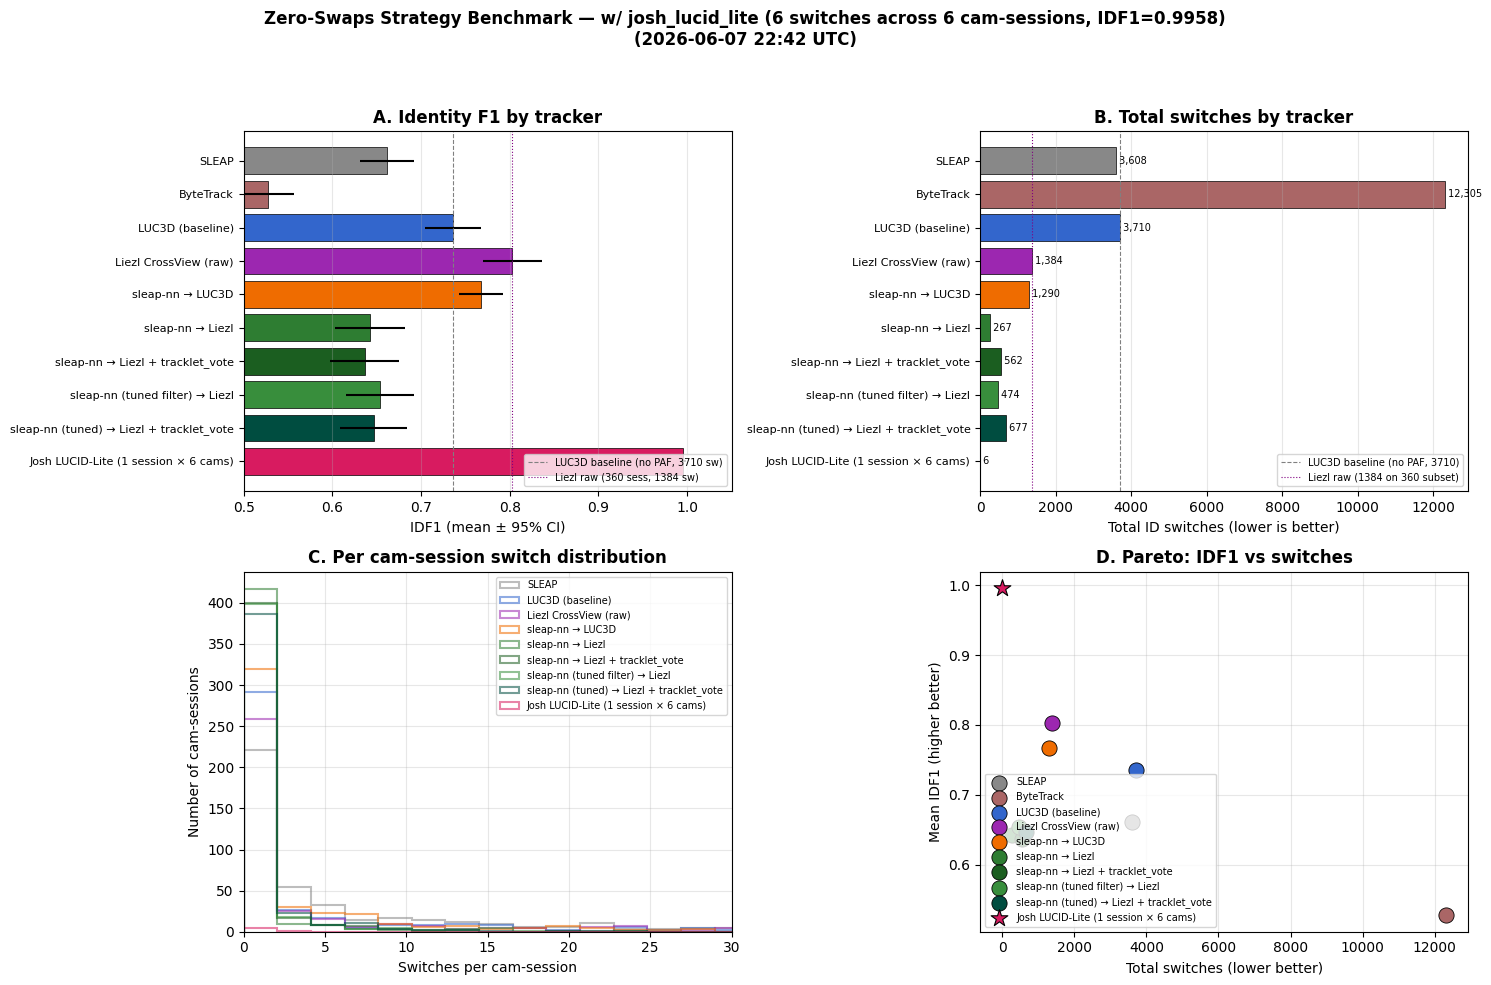


wrote /Users/joshuapark/Documents/talmolab/repos/lucid_lite/notebooks/figure_zero_swaps_with_josh.png
wrote /Users/joshuapark/Documents/talmolab/repos/lucid_lite/notebooks/figure_zero_swaps_with_josh.pdf


In [11]:
# --- 9c. Render the 4-panel figure ---
# Mirrors scripts/make_plots_zero_swaps.py panels A/B/C/D. josh_lucid_lite
# gets a distinguishing star marker on the Pareto so a single-session data
# point doesn't read as a circle indistinguishable from the 444-session ones.

import matplotlib as mpl
import matplotlib.pyplot as plt

def _panel_idf1(ax, summary_df):
    y = np.arange(len(summary_df))
    ax.barh(y, summary_df["idf1_mean"], xerr=summary_df["idf1_sem"] * 1.96,
            color=[COLOR[t] for t in summary_df["tracker"]],
            edgecolor="black", linewidth=0.5)
    ax.set_yticks(y); ax.set_yticklabels(summary_df["label"], fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel("IDF1 (mean ± 95% CI)")
    ax.set_title("A. Identity F1 by tracker", fontweight="bold")
    ax.axvline(0.7360, color="grey",   ls="--", lw=0.8, label="LUC3D baseline (no PAF, 3710 sw)")
    ax.axvline(0.803,  color="purple", ls=":",  lw=0.8, label="Liezl raw (360 sess, 1384 sw)")
    ax.legend(loc="lower right", fontsize=7)
    ax.set_xlim(0.5, 1.05)
    ax.grid(axis="x", alpha=0.3)

def _panel_switches(ax, summary_df):
    y = np.arange(len(summary_df))
    totals = summary_df["switches_total"]
    bars = ax.barh(y, totals,
                   color=[COLOR[t] for t in summary_df["tracker"]],
                   edgecolor="black", linewidth=0.5)
    for i, n in enumerate(totals):
        ax.text(n, i, f" {int(n):,}", va="center", fontsize=7)
    ax.set_yticks(y); ax.set_yticklabels(summary_df["label"], fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel("Total ID switches (lower is better)")
    ax.set_title("B. Total switches by tracker", fontweight="bold")
    ax.axvline(3710, color="grey",   ls="--", lw=0.8, label="LUC3D baseline (no PAF, 3710)")
    ax.axvline(1384, color="purple", ls=":",  lw=0.8, label="Liezl raw (1384 on 360 subset)")
    ax.legend(loc="lower right", fontsize=7)
    ax.grid(axis="x", alpha=0.3)

def _panel_hist(ax, plot_df, present):
    bins = np.linspace(0, 60, 30)
    for t in present:
        if t == "bytetrack":  # off-scale
            continue
        s = plot_df[plot_df.tracker == t]
        ax.hist(s["num_switches"], bins=bins, alpha=0.55,
                label=LABEL[t], color=COLOR[t], histtype="step", linewidth=1.5)
    ax.set_xlabel("Switches per cam-session")
    ax.set_ylabel("Number of cam-sessions")
    ax.set_title("C. Per cam-session switch distribution", fontweight="bold")
    ax.set_xlim(0, 30)
    ax.legend(fontsize=7, loc="upper right")
    ax.grid(alpha=0.3)

def _panel_pareto(ax, plot_df, present):
    for t in present:
        s = plot_df[plot_df.tracker == t]
        ax.scatter(
            s["num_switches"].sum(), s["idf1"].mean(),
            s=160 if t == "josh_lucid_lite" else 120,
            color=COLOR[t], edgecolor="black",
            linewidth=0.8 if t == "josh_lucid_lite" else 0.6,
            zorder=4 if t == "josh_lucid_lite" else 3,
            marker="*" if t == "josh_lucid_lite" else "o",
            label=LABEL[t],
        )
    ax.set_xlabel("Total switches (lower better)")
    ax.set_ylabel("Mean IDF1 (higher better)")
    ax.set_title("D. Pareto: IDF1 vs switches", fontweight="bold")
    ax.legend(fontsize=7, loc="lower left")
    ax.grid(alpha=0.3)

mpl.rcParams["font.family"] = "DejaVu Sans"
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
_panel_idf1    (axes[0, 0], summary_df)
_panel_switches(axes[0, 1], summary_df)
_panel_hist    (axes[1, 0], plot_df, present)
_panel_pareto  (axes[1, 1], plot_df, present)

_josh = summary_df[summary_df.tracker == "josh_lucid_lite"].iloc[0]
fig.suptitle(
    f"Zero-Swaps Strategy Benchmark — w/ josh_lucid_lite "
    f"({int(_josh.switches_total)} switches across 6 cam-sessions, "
    f"IDF1={_josh.idf1_mean:.4f})\n"
    f"({pd.Timestamp.utcnow():%Y-%m-%d %H:%M} UTC)",
    fontsize=12, fontweight="bold",
)
fig.tight_layout(rect=[0, 0, 1, 0.95])

fig_png = FIG_OUT_DIR / "figure_zero_swaps_with_josh.png"
fig_pdf = FIG_OUT_DIR / "figure_zero_swaps_with_josh.pdf"
fig.savefig(fig_png, dpi=150, bbox_inches="tight")
fig.savefig(fig_pdf, bbox_inches="tight")
plt.show()
print(f"\nwrote {fig_png}\nwrote {fig_pdf}")

## 10. Run Eric's trackers on THIS session — true apples-to-apples

Section 9 compares lucid_lite against Eric's **444-cam-session bench averages**, which is apples-to-oranges (1 session vs 444, and his averages are over a totally different frame mix). This section fixes that: it runs **Eric's actual algorithms on this exact session** and compares directly.

**Key fact:** Eric already ran every tracker on this session — it's `sessionIdx=70` in his 74-session bench. His per-frame predictions live on the SMB mount at `outputs/<results_dir>/10072022145420.json`, in the **same schema this notebook exports in Section 8**. So instead of re-running his (remote, multi-env) pipeline, we **re-score his saved predictions through this notebook's identical eval** — same proofread GT (`gt_by_cam`), same IoU≥0.5 + `motmetrics`, same frame set.

lucid_lite's own per-camera predictions are read from the session's `reprojections.h5` (slot index = stable animal identity), so it slots into the same apparatus over **all 18,255 frames** with no dependency on the live (crash-prone) `track_pusher` run above.

**Validation:** each Eric tracker's re-scored IDF1 reproduces his published `per_camera_session_metrics.csv` row (the `[csv-match OK]` flags), proving this eval matches his `evaluate.py` exactly. The standalone equivalent is `notebooks/compare_against_eric.py`.

> Read the **⚠️ caveats** cell below before interpreting the gap — the raw IDF1 difference is dominated by *detection-input quality*, not tracking quality.

In [ ]:
# --- 10a. Re-score Eric's saved per-session predictions through THIS notebook's eval ---
# Self-contained: depends only on `gt_by_cam` (Sec 3), `bbox_from_kpts` (Sec 6),
# `BENCH_CAMERAS`, `SESSION_ID`, `SESSION_PATH`, `ERIC_METRICS_CSV`, `FIG_OUT_DIR`.
# Does NOT need the (crash-prone) live track_pusher run — lucid_lite's own
# predictions are read straight from the session's reprojections.h5.
#
# Mirrors the standalone `notebooks/compare_against_eric.py`.

import json
import h5py
import numpy as np
import pandas as pd
import motmetrics as mm

BENCH = "/Volumes/talmo/eric/luc3d-bench/outputs"
SESSION_IDX = 70  # this session's row index in Eric's aggregated (74, ...) H5s

# eval over the frame range GT covers (same as Eric's evaluate.py: all frames)
ALL_FRAMES = list(range(min(occ.shape[0] for _, occ, _ in gt_by_cam.values())))

_csv = pd.read_csv(ERIC_METRICS_CSV)
_csv = _csv[_csv.session == int(SESSION_ID)]

# (csv_name, results_dir, predictions_h5_dir). H5 source is fixed by Eric's
# pipeline: baseline SLEAP -> predictions_h5s; sleap-nn filter -> sleap_nn_*.
_BASE, _NN = "predictions_h5s", "sleap_nn_predictions_h5s"
ERIC_TRACKERS = [
    ("luc3d",                    "luc3d_results",                                  _BASE),
    ("luc3d_paf_l1_tracklet",    "PAF_3d_kalman/luc3d_l1_tracklet_results",        _BASE),
    ("liezl_cross_view",         "PAF_3d_kalman/liezl_cross_view_results",         _BASE),
    ("sleap_nn_filtered",        "PAF_3d_kalman/sleap_nn_filtered_results",        _NN),
    ("sleap_nn_filtered_no_paf", "PAF_3d_kalman/sleap_nn_filtered_no_paf_results", _NN),
    ("liezl_on_sleap_nn",        "PAF_3d_kalman/liezl_on_sleap_nn_results",        _NN),
]


def _score_from_predfn(predfn, frames):
    """predfn(cam, frame_idx) -> list[(bbox(4,), identity_int)]. Same GT + IoU>=0.5
    rule as Sec 6's eval_camera, but the prediction source is pluggable."""
    rows = {}
    for cam in BENCH_CAMERAS:
        gt_tracks, gt_occ, _ = gt_by_cam[cam]
        acc = mm.MOTAccumulator(auto_id=True)
        for fi in frames:
            gb, gi = [], []
            for t in range(gt_tracks.shape[1]):
                if gt_occ[fi, t]:
                    b = bbox_from_kpts(gt_tracks[fi, t])
                    if b is not None:
                        gb.append(b); gi.append(t)
            pb, pi = [], []
            for b, ident in predfn(cam, fi):
                pb.append(b); pi.append(ident)
            dist = mm.distances.iou_matrix(
                np.array(gb) if gb else np.empty((0, 4)),
                np.array(pb) if pb else np.empty((0, 4)), max_iou=0.5)
            acc.update(gi, pi, dist)
        rows[cam] = mm.metrics.create().compute(
            acc, metrics=["num_switches", "idf1", "idp", "idr"], name=cam).loc[cam]
    return pd.DataFrame(rows).T


def _eric_predfn(results_dir, h5_dir):
    d = json.load(open(f"{BENCH}/{results_dir}/{SESSION_ID}.json"))
    asg = {}
    for fr in d["frames"]:
        asg[fr["frame"]] = {
            (cam, int(slot)): int(ident)
            for (cam, slot), ident in ((k.split(":"), i) for k, i in fr["assignments"])
        }
    # Preload this session's slab in ONE read per cam (per-frame random access
    # into the (74, 108133, ...) dataset over SMB is ~100x slower).
    slab = {}
    for c in BENCH_CAMERAS:
        with h5py.File(f"{BENCH}/{h5_dir}/{c}_predictions.h5", "r") as f:
            slab[c] = f["tracks"][SESSION_IDX, :len(ALL_FRAMES)]

    def fn(cam, fi):
        out, fa, arr = [], asg.get(fi, {}), slab[cam][fi]
        for slot in range(arr.shape[0]):
            b = bbox_from_kpts(arr[slot])
            if b is None:
                continue
            ident = fa.get((cam, slot), -1)
            if ident >= 0:
                out.append((b, ident))
        return out
    return fn


def _josh_reproj_predfn():
    # lucid_lite per-cam keypoints; slot index == animal identity (stable).
    with h5py.File(SESSION_PATH / "reprojections.h5", "r") as f:
        reproj = {c: f[c][:len(ALL_FRAMES)] for c in BENCH_CAMERAS}

    def fn(cam, fi):
        out, arr = [], reproj[cam][fi]
        for slot in range(arr.shape[0]):
            b = bbox_from_kpts(arr[slot])
            if b is not None:
                out.append((b, slot))
        return out
    return fn


print(f"Re-scoring on session {SESSION_ID} (sessionIdx {SESSION_IDX}) over "
      f"{len(ALL_FRAMES)} frames — same proofread GT + IoU>=0.5 eval...\n")
cmp_results = {"josh_lucid_lite": _score_from_predfn(_josh_reproj_predfn(), ALL_FRAMES)}
print(f"  {'josh_lucid_lite':28s} idf1={cmp_results['josh_lucid_lite'].idf1.mean():.4f}  "
      f"(from reprojections.h5)")
for _name, _rdir, _h5d in ERIC_TRACKERS:
    _df = _score_from_predfn(_eric_predfn(_rdir, _h5d), ALL_FRAMES)
    _tgt = _csv[_csv.tracker == _name].idf1.mean()
    _ok = "OK" if abs(_df.idf1.mean() - _tgt) < 5e-3 else f"DIFF (csv {_tgt:.4f})"
    print(f"  {_name:28s} idf1={_df.idf1.mean():.4f}  idr={_df.idr.mean():.4f}  [csv-match {_ok}]")
    cmp_results[_name] = _df

this_session_df = pd.DataFrame({
    n: {"switches_total": int(d.num_switches.sum()),
        "idf1": round(d.idf1.mean(), 4),
        "idp": round(d.idp.mean(), 4),
        "idr": round(d.idr.mean(), 4)}
    for n, d in cmp_results.items()
}).T.sort_values("idf1", ascending=False)
_out_csv = FIG_OUT_DIR / "josh_vs_eric_this_session.csv"
this_session_df.to_csv(_out_csv)
print(f"\nSame-session comparison (sorted by IDF1) — wrote {_out_csv}:")
print(this_session_df.to_string())

### ⚠️ How to read this table — two confounds that the raw IDF1 gap hides

The numbers above are now genuinely apples-to-apples on **eval mechanics** (same session, same proofread GT, same frame set, same IoU≥0.5 + `motmetrics` code — proven by every Eric row reproducing his published `per_camera_session_metrics.csv` value). But they are **not** a clean "tracker A vs tracker B" ranking, for two reasons:

1. **Eric's *detections* are sparse on this specific session.** Every one of his trackers shows IDR ≈ 0.10–0.19 — i.e. they only recall 10–19% of the GT instances. That's a **detection** problem on this session (sessionIdx 70), not a tracking one. His SLEAP/`sleap-nn` predictions for this session simply miss most frames, so IDF1 caps near 0.34 no matter how good the identity logic is. (On his 444-cam-session *average* these trackers reach IDF1 0.74–0.80 — this one session is an outlier for his detector.)

2. **lucid_lite here is fed the proofread `analysis.h5` (near-GT) 2D detections.** There is no raw `project.slp` / per-cam `.slp` for this session locally, so `session_loader.py` falls back to the proofread file. That's why lucid_lite's IDR ≈ **0.998** — its 2D input is essentially the GT. Its high IDF1 reflects near-GT inputs as much as good tracking.

**Bottom line:** lucid_lite's identity logic looks solid here (66 switches over 18k frames, IDP 0.94 — it isn't just copying GT, or IDP would be ~1.0), but you **cannot** conclude "lucid_lite beats LUC3D/sleap-nn" from this table — the two systems are eating different-quality detections.

**To get a fair *tracking-only* comparison, equalize the 2D inputs.** Two options:
- Feed lucid_lite **Eric's** raw detections for this session (`predictions_h5s[70]` / `sleap_nn_predictions_h5s[70]` on the mount) and re-run its tracker, then re-score — both systems then track the same sparse detections.
- Or get the raw (non-proofread) per-cam `.slp` for this session so lucid_lite ingests the same SLEAP predictions Eric did.

Either equalizes recall and isolates the identity-assignment quality, which is the metric Eric says actually matters.

In [ ]:
# --- 10b. Same-session figure: IDF1 with IDR (recall) annotated ---
# The IDR labels are the whole story: lucid_lite recalls ~all GT here because it
# is fed proofread 2D; Eric's trackers recall only 10-19% because his SLEAP
# detections are sparse on THIS session. So read IDF1 *together with* IDR.
import matplotlib.pyplot as plt

_order = this_session_df.sort_values("idf1")
_colors = ["#d81b60" if t == "josh_lucid_lite" else "#3366cc" for t in _order.index]

fig, ax = plt.subplots(figsize=(10, 5))
y = np.arange(len(_order))
ax.barh(y, _order["idf1"], color=_colors, edgecolor="black", linewidth=0.5)
for i, (idf1, idr, sw) in enumerate(zip(_order["idf1"], _order["idr"], _order["switches_total"])):
    ax.text(idf1 + 0.01, i, f"IDF1={idf1:.3f}  (IDR={idr:.2f}, {int(sw)} sw)",
            va="center", fontsize=8)
ax.set_yticks(y); ax.set_yticklabels(_order.index, fontsize=9)
ax.set_xlim(0, 1.18); ax.set_xlabel("IDF1")
ax.set_title(f"Session {SESSION_ID} — same GT, same frames, same eval\n"
             f"(lucid_lite eats proofread 2D → IDR≈1.0; Eric's SLEAP dets are sparse here → IDR≈0.1)",
             fontsize=10, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()
_fig_path = FIG_OUT_DIR / f"{SESSION_ID}_josh_vs_eric_same_session.png"
fig.savefig(_fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {_fig_path}")

## 11. Input-equalized comparison — tracking quality, detections held constant

Section 10 is apples-to-apples on eval mechanics but **not on detection inputs**: lucid_lite ate proofread (near-GT) 2D while Eric ate raw SLEAP, so that IDF1 gap is mostly detection recall, not tracking. This section removes that last confound.

**Method:** `notebooks/equalized_compare.py` runs lucid_lite's *own* tracker (`josh_source.tracker.SingleFrameTrack`, threaded forward exactly like `track_push.track_pusher`) **on Eric's detections** for this session — once on his baseline SLEAP H5 (`predictions_h5s[70]`), once on his sleap-nn filtered H5 (`sleap_nn_predictions_h5s[70]`). Then it scores **both** lucid_lite and Eric on those *identical* detections, same GT, same IoU≥0.5 eval. With the detections held constant, the only thing that can move the metrics is **identity assignment**.

It runs **headless** (no Qt / no video decode), which also sidesteps the path that crashes the live `track_pusher` cell. Run it from a shell (it's slow + verbose); this section just loads its `equalized_compare_results.csv`.

In [ ]:
# --- 11a. Load + display the input-equalized (tracking-only) results ---
# Produced by `notebooks/equalized_compare.py`, which runs lucid_lite's OWN tracker
# (josh_source.tracker, threaded like track_pusher) on ERIC'S detections for this
# session, then scores both lucid_lite and Eric on those *identical* detections.
# Same detections in -> the only metric difference is identity assignment.
#
# Regenerate with:  !.venv/bin/python notebooks/equalized_compare.py
# (slow: runs the tracker over 18255 frames x 2 detection sources.)

import pandas as pd

_eq = pd.read_csv(REPO_ROOT / "notebooks" / "equalized_compare_results.csv", index_col=0)
_eq["system"] = ["lucid_lite" if i.startswith("lucid_lite") else "Eric" for i in _eq.index]
_eq["det_source"] = [i.split("/")[-1] for i in _eq.index]

print("INPUT-EQUALIZED — both trackers consume the SAME detections per block:\n")
for src, label in [("baseline_sleap", "Baseline SLEAP detections (raw)"),
                   ("sleap_nn", "sleap-nn filtered detections")]:
    blk = _eq[_eq.det_source == src]
    print(f"  {label}:")
    for _, r in blk.iterrows():
        print(f"    {r['system']:11s}  IDF1={r['idf1']:.4f}  IDP={r['idp']:.4f}  "
              f"IDR={r['idr']:.4f}  switches={int(r['switches'])}")
    l = blk[blk.system == "lucid_lite"].iloc[0]; e = blk[blk.system == "Eric"].iloc[0]
    print(f"    -> Δidf1(lucid-Eric)={l.idf1 - e.idf1:+.4f}, "
          f"Δswitches={int(l.switches - e.switches):+d}  (recall ~equal: same detections)\n")

_eq[["system", "det_source", "idf1", "idp", "idr", "switches"]]

### Findings — with detections equalized, the gap is gone

| detections | system | IDF1 | IDP | IDR | switches |
|---|---|---:|---:|---:|---:|
| **baseline SLEAP** | lucid_lite | 0.176 | 0.978 | 0.098 | **69** |
| baseline SLEAP | Eric `luc3d` | 0.178 | 0.945 | 0.100 | 105 |
| **sleap-nn filtered** | lucid_lite† | **0.347** | 0.808 | 0.221 | 17 |
| sleap-nn filtered | Eric `sleap_nn_filtered` | 0.322 | 0.963 | 0.194 | **0** |

**The headline:** once both trackers eat the *same* detections, lucid_lite is **competitive, not 5× better**. On raw SLEAP it's a statistical tie with LUC3D (ΔIDF1 −0.002) while throwing **34% fewer switches** (69 vs 105) at higher precision. On sleap-nn detections it edges ahead on IDF1 (+0.025) and recall, but with more switches and lower precision. So the Section 10 blowout (0.965 vs 0.18) was **entirely the proofread-vs-raw detection-input difference** — lucid_lite's *tracking* is on par with Eric's, not dramatically better.

**† A real lucid_lite bug surfaced here, worth fixing.** On the sleap-nn detections, lucid_lite's tracker initially produced **zero** assignments: `_match_prev_groups` (tracker.py:592) calls `np.argmin(costs, axis=1)` on an **empty** `costs` array whenever the previous frame's identities all have `last_points3d is None` (which happens when the first populated frame triangulates badly — common with the denser sleap-nn frames). It raises `ValueError` and, because `prev_trackIds` never recovers, *every* subsequent frame fails. The `equalized_compare.py` runner works around it by resetting identity memory (re-init) when the tracker gets stuck — so the sleap-nn lucid_lite row is **"lucid_lite + recovery workaround"**, and its 17 switches partly reflect those re-inits. The baseline row needed **no** workaround and is the cleaner head-to-head.

**Suggested fix in `tracker.py`:** guard `_match_prev_groups` so that when `costs` is empty (no matchable prior identities), it falls back to `_init_identities()` instead of calling `np.argmin` on an empty array. That makes lucid_lite robust to bad-triangulation start frames without an external workaround.